
# Diseño de software

----

Paradigma orientado a objetos (OOP)

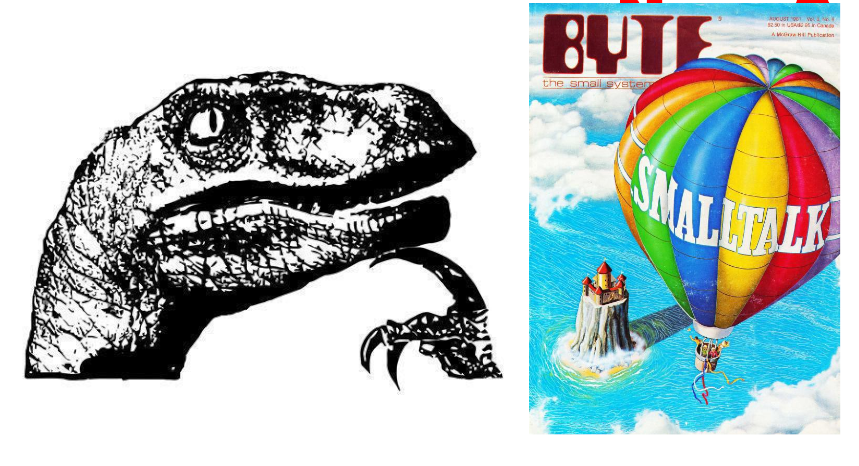



### Aclaraciónes previas

---

- Existen muchos paradigmas de programación, pero pocos lenguajes que implementan uno solo:
    - Funcional (Haskell)
    - Procedural (ASM, C)
    - Lógico (Prolog)
    - Orientado a objetos (Smalltalk)
- La mayoría de los lenguajes modernos son multiparadigma.
- Pero casi todos los lenguajes se implementan sobre un paradigma en particular.
- Python se implementa sobre OOP (**O**bject **O**riented **P**aradigm).
- La mayoría de los científicos sabe programar en algún lenguaje proceduralmente.   
- Todo de acá en mas esta sacado de Wikipedia y sus links (excepto que diga lo contrario).

### Aclaraciones previas

---

- El OOP **no** es la verdad de la milanesa.
- Fue el gran motor del crecimiento de software desde los '90.
 
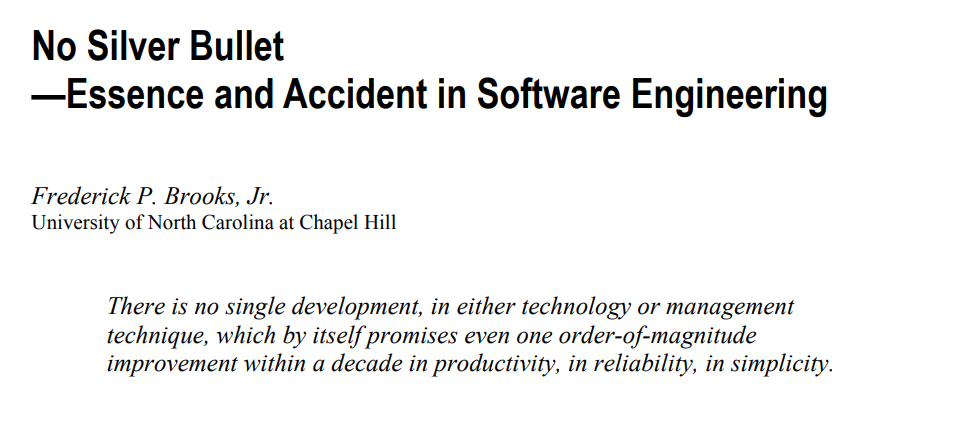

- Es una de las dos grandes soluciones al problema del *shared state* de lenguajes básicos

   - OOP: No comparta estado nada (No share)
   - PF: No tengas estado (No state).

## Vamos con un ejemplo procedural

----

Representemos una persona con un diccionario

In [ ]:
persona = {
    "nombre": "tito",
    "sexo": "masculino",
    "edad": 10, 
    "altura": 1.60}

Hagamos un validador de los tipos de persona

In [ ]:
def validar_persona(p):
    nombre, sexo = p.get("nombre"), p.get("sexo")
    edad, altura = p.get("edad"), p.get("altura")
    return (
        type(nombre) == str and nombre and
        sexo in ("masculino", "femenino") and
        type(edad) == int and (0 < edad < 120) and
        type(altura) == float and (.2 <= altura <= 2.30))
        
validar_persona(persona)

### Pero tu jefe te cambia los requerimientos
---

```python
def validar_persona(p):
    nombre, genero = p.get("nombre"), p.get("género")
    edad, altura = p.get("edad"), p.get("altura")
    return (
        type(nombre) == str and nombre and
        genero in ("varón", "mujer") and
        type(edad) == int and (0 < edad < 120) and
        type(altura) == float and (.2 <= altura <= 2.30))
```

<small>Siglo XXI, quiero que soportes 70 generos como facebook.</small>

<small>Quiero trabajar internacionalmente</small>

<small>Solo operamos a mayores de edad segun el pais.</small>

<small>Las medidas de altura son en centímetros.<small>

### Cuál es el problema?
----------

- Los requerimientos cambian.
- Los programas representan normalmente abstracciones de algún problema.
- El acoplamiento es un problema semántico y no sintáctico.

> El **acoplamiento** es la forma y nivel de interdependencia entre módulos de software; una medida de qué tan cercanamente conectados están dos rutinas o módulos de software; así como el grado de fuerza de la relación entre módulos.
>  
> El acoplamiento está comúnmente contrastado con la **cohesión**. Un bajo acoplamiento normalmente se 
> correlaciona con una alta cohesión. El bajo acoplamiento es una señal de un sistema con un buen diseño.

### Soluciones
----

Este es el problema que suele solucionar el OOP.

¿alguna idea? (Piensen out of the box)

- Volvamos al acoplamiento mas evidente.
- Hagámoslo explícito.

## POO
---

Vamos de a poco formalizando (En el sentido ingenieril de la palabra)

**Estos datos, guardan algún estado que representan a la persona**

```python
persona = {
    "nombre": "tito", "sexo": "masculino",
    "edad": 10, "altura": 1.60}
```
    
**Esto es "lógica", representan algún tipo de comportamiento que se puede hacer al manipular los datos**

```python
def validar_persona(p):
    nombre, sexo = p.get("nombre"), p.get("sexo")
    edad, altura = p.get("edad"), p.get("altura")
    return (...)
```

**Tanto los datos como la lógica se guardan cada una en un lugar único de memoria que se accede por su nombre**

In [ ]:
hex(id(persona)), hex(id(validar_persona))

### POO - Definición formal
----

Un objeto es algo que tiene

- Estado
- Comportamiento
- Identitad

```ipython
>>> p0 = Persona(nombre="tito", sexo= "masculino", edad=10, altura=1.6)
>>> p0.nombre, p0.validar()
("tito", True)
>>> p1 = Persona(nombre="tito", sexo= "masculino", edad=10, altura=1.6)
>>> p1.nombre, p1.validar()
("tito", True)
>>> hex(id(p0)), hex(id(p1))
('0x7f61680be120', '0x7f6168044b85')
```

## POO - Message passing

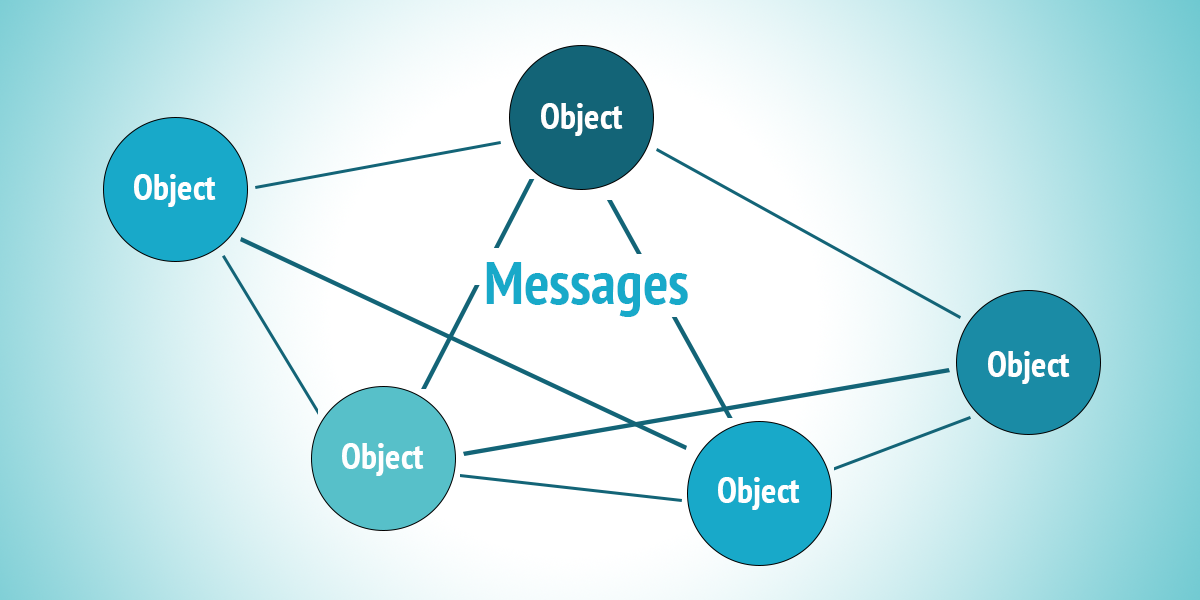

- Analogía de la célula.
- Cuando un objeto no sabe que hacer se emite un mensaje a un objeto colaborador.
- El colaborador responde con otro mensaje.
- Los mensajes y las respuestas son objetos (los detalles de implementación más adelante).
- Lo unico que puede suceder en OOP, con sintaxis Python, es `objeto.mensaje(colaborador)`

### POO - Clases
----

- Se pueden implementar objetos de varias formas. 
- Python implementa objetos con **clases** (`class`).
- Una clase es un **blue-print** (plano) de objetos similares.
- Las clases **instancian** (crean) objetos.
- En Python las clases son objetos (de hecho **TODO** es un objeto en Python).

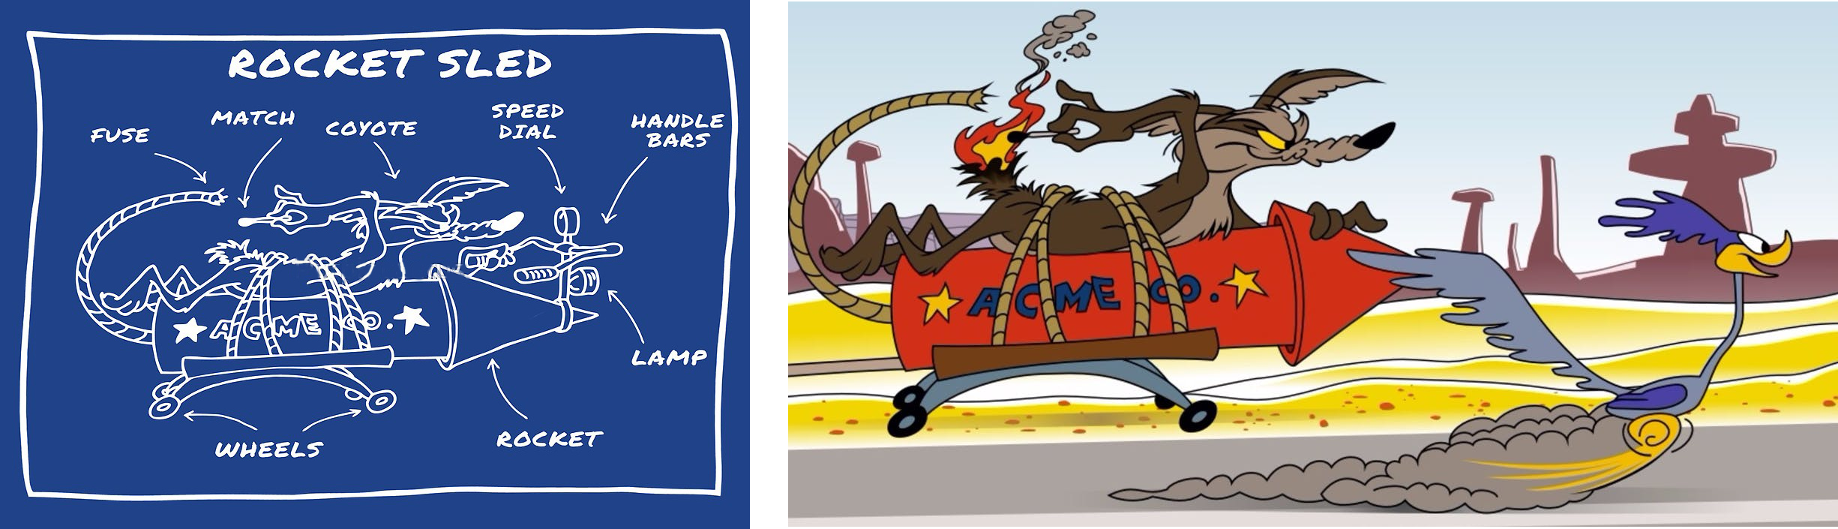

POO - Clases - Estado e identidad
----

In [ ]:
class Persona:
    def __init__(self, nombre, sexo, edad, altura):
        self.nombre = nombre
        self.sexo = sexo
        self.edad = edad
        self.altura = altura

In [ ]:
Persona("tito", "masculino", 10, 1.60), Persona("tito", "masculino", 10, 1.60).sexo

### POO - Clases - Comportamiento

In [ ]:
class Persona:
    def __init__(self, nombre, sexo, edad, altura):
        self.nombre = nombre
        self.sexo = sexo
        self.edad = edad
        self.altura = altura
        
    def validar(self):
        return (
            type(self.nombre) == str and self.nombre and
            self.sexo in ("masculino", "femenino") and
            type(self.edad) == int and (0 < self.edad < 120) and
            type(self.altura) == float and (.2 <= self.altura <= 2.30))

p = Persona("tito", "masculino", 10, 1.60)
p .validar()

### POO - Clases - Mejorando

la funcion `isinstance(obj, clase)` verifica si un objeto es de una clase dada

In [ ]:
class Persona:
    def __init__(self, nombre, sexo, edad, altura):
        self.nombre = nombre
        self.sexo = sexo
        self.edad = edad
        self.altura = altura
        
    def validar(self):
        return (
            isinstance(self.nombre, str) and self.nombre and
            self.sexo in ("masculino", "femenino") and
            isinstance(self.edad, int) and (0 < self.edad < 120) and
            isinstance(self.altura, float) and (.2 <= self.altura <= 2.30))

p = Persona("tito", "masculino", 10, 1.60)
p.validar()

## Consecuencia de implenetación de POO en Python

- Si Python implementa **solo** objetos.
- Y los modela con clases.

Entonces

> **Todo en python fue Creado con una clase**

### Python Built-in ~Types~ Classes

----

<table style="width=80%">
<thead>
<tr class="header">
    <th><p><del>Types</del><br>Classes</p></th>
<th><p>Mutable?</p></th>
<th><p>Description</p></th>
    <th><p><del>Syntax example</del><br>Syntactic Sugar</p></th>
</tr>
</thead>
<tbody>

<tr class="odd">
<td><p><code>bool</code></p></td>
<td><p>No</p></td>
<td><p>Valor Booleano.</p></td>
<td><p><code>True</code><br />
<code>False</code></p></td>
</tr>

<tr class="odd">
<td><p><code>bytes</code></p></td>
<td><p>No</p></td>
<td><p>Sequencia de bytes.</p></td>
<td><p><code>b'Some ASCII'</code><br />
<code>b"Some ASCII"</code><br />
<code>bytes([119, 105, 107, 105])</code></p></td>
</tr>

<tr class="even">
<td><p><code>complex</code></p></td>
<td><p>No</p></td>
<td><p>Numero complejo.</p></td>
<td><p><code>3+2.7j</code></p></td>
</tr>

<tr class="odd">
<td><p><code>dict</code></p></td>
<td><p>Sí</p></td>
<td><p>Arreglo asociativo entre llave y valor.</p></td>
<td><p><code>{'key1': 1.0, 3: False}</code></p></td>
</tr>

<tr class="odd">
<td><p><code>float</code></p></td>
<td><p>No</p></td>
<td><p>Número flotante</p></td>
<td><p><code>3.1415927</code></p></td>
</tr>

<tr class="even">
<td><p><code>frozenset</code></p></td>
<td><p>No</p></td>
<td><p>Conjunto inmutable (sin orden).</p></td>
<td><p><code>frozenset([4.0, 'string', True])</code></p></td>
</tr>
<tr class="odd">
<td><p><code>int</code></p></td>
<td><p>No</p></td>
<td><p>Entero</p></td>
<td><p><code>42</code></p></td>
</tr>

<tr class="even">
<td><p><code>list</code></p></td>
<td><p>Sí</p></td>
<td><p>Lista ordenada mutable.</p></td>
<td><p><code>[4.0, 'string', True]</code></p></td>
</tr>

<tr class="odd">
<td><p><code>NoneType</code></p></td>
<td><p>No</p></td>
<td><p>Ausencia de valor.</p></td>
<td><p><code>None</code></p></td>
</tr>

<tr class="odd">
<td><p><code>set</code></p></td>
<td><p>Sí</p></td>
<td><p>Conjunto mutable (sin orden).</p></td>
<td><p><code>{4.0, 'string', True}</code></p></td>
</tr>

<tr class="even">
<td><p><code>str</code></p></td>
<td><p>No</p></td>
<td><p>Cadena de caracteres.</p></td>
<td><p><code>'Wikipedia'</code><br />
<code>"Wikipedia"</code><br />
<code>"""Spanning</code><br />
<code>multiple</code><br />
<code>lines"""</code></p></td>
</tr>

<tr class="odd">
<td><p><code>tuple</code></p></td>
<td><p>No</p></td>
<td><p>Lista ordenada inmutable.</p></td>
<td><p><code>(4.0, 'string', True)</code></p></td>
</tr>
</tbody>
</table>

## Azucar sintáctico

Es un término acuñado por *Peter J. Landin* en 1964 para referirse a los **añadidos a la sintaxis de un lenguaje de programación diseñados para hacer algunas construcciones más fáciles de leer o expresar**. 

El azúcar sintáctico  puede ser eliminado del lenguaje sin ningún efecto en la potencia del lenguaje: la funcionalidad y potencia de expresión será la misma.

Los procesadores de lenguajes, incluyendo compiladores, analizadores (parsers), y similares, en ocasiones expanden construcciones «azucaradas» en construcciones más fundamentales antes del procesado, un proceso a veces llamado "desazucarización".

## POO - Propiedades
---

- Encapsulamiento.
- Herencia.
- Polimorfismo.

### POO - Propiedades - *Encapsulamiento*

---

Se refiere a dos conceptos separados, y en algunos casos a los dos al mismo tiempo:

- La capacidad del lenguaje para mezclar datos y métodos que operan sobre estos datos.
- Un mecanismo del lenguaje para restringir la modificación de los componentes del objeto.

Cada objeto está aislado del exterior, es un módulo natural, y la aplicación entera se reduce a un agregado o rompecabezas de objetos. El aislamiento protege a los datos asociados de un objeto contra su modificación por quien no tenga derecho a acceder a ellos, eliminando efectos secundarios e interacciones.

### POO - Propiedades - *Encapsulamiento*

---

```java
import org.apache.commons.text.WordUtils;

public class Persona {
    private String nombre;
    
    public Persona(String nombre){
        this.nombre = WordUtils.capitalizeFully(nombre);
    }
    
    public String getNombre(){
        return this.nombre;
    }
    
    public void setNombre(String nombre){
        this.nombre = WordUtils.capitalizeFully(nombre);
    }
}
```

### POO - Propiedades - *Encapsulamiento*

---

**Esto no anda**
```java
Persona p = new Persona("tito");
p.nombre = "toto";
p.nombre;
```

**Esto si anda**

```java
Persona p = new Persona("tito");
p.setNombre("toto carloto");
p.getNombre(); // Toto Carloto
```

### POO - Propiedades - *Encapsulamiento*

---

- Python no tiene nada parecido a lo que tiene Java/C++/C#
- En remplazo tenemos algunos _name mangling_ y **propiedades**

Las cosas privadas empiezan con **un**/**1** under_score () (pero nunca empiezan y terminan con 2)

In [ ]:
class Persona:
    def __init__(self, nombre):
        self._nombre = nombre.title() # esto se considera privado
        
    @property
    def nombre(self):
        return self._nombre
        
    @nombre.setter
    def nombre(self, nombre):
         self._nombre = nombre.title()

### POO - Propiedades - *Encapsulamiento*

---

In [ ]:
p = Persona("tito")
p.nombre = "toto carloto"
p.nombre

In [ ]:
p._nombre

In [ ]:
print(dir(p))

### POO - Propiedades - *Encapsulamiento*

---

En la práctica suele usarse 1 _under-score_, para que si alguien quiera usar estos atributos privados, los haga bajo su propio riesgo

In [ ]:
class Persona:
    def __init__(self, nombre):
        self._nombre = nombre.title() # esto se considera privado
        
    @property
    def nombre(self):
        return self._nombre
        
    @nombre.setter
    def nombre(self, nombre):
         self._nombre = nombre.title()

In [ ]:
p = Persona("tito")
p.nombre = "toto carloto"
print(p.nombre)

p._nombre = "coso"
print(p.nombre)

### POO - Propiedades - Herencia
----



- En la programación orientada a objetos, la herencia es el mecanismo de basar un objeto **o** clase en otro objeto (herencia basada en prototipo) u otra clase (herencia basada en clase), reteniendo una implementación similar. 
- También se define como derivar nuevas clases (subclases) de las existentes (súper clase o clase base) y formarlas en una jerarquía de clases.
- En Python la herencia es **explícita** o **implícita**, pero obligatoria:

In [ ]:
class Foo(object): 
    pass

class Foo: 
    pass

### POO - Propiedades - Herencia

#### Clases abstractas. 
----

Quiero modelar estos dos animales mamiferos

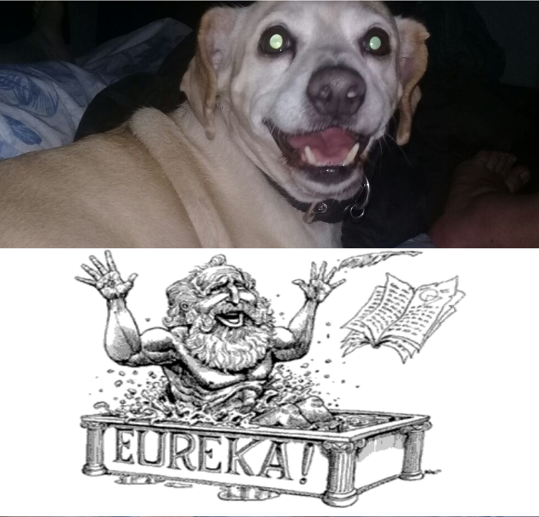

### POO - Propiedades - Herencia
----------

In [ ]:
class Animal:
    def __init__(self, nombre):
        self._nombre = nombre
        self._vivo = True

    @property
    def nombre(self):
        return self._nombre.title()
    
    def vivir(self):
        return "viviendo" if self._vivo else "estoy muerto"    
    def morirse(self):
        self._vivo = False

class Mamifero(Animal):
    def lactar(self):
        return "lactando"
    def nacer(self):
        return "de una hembra"
    
class Perro(Mamifero): 
    def ladrar(self): 
        return "guau"
    
class Humano(Mamifero): 
    def saludar(self):
        return "hola"

### POO - Propiedades - Herencia
----

In [ ]:
arqui_p = Perro("Arquimedes")
arqui_h = Humano("Arquimedes")
type(arqui_p), type(arqui_h)

In [ ]:
arqui_p.ladrar(), arqui_p.saludar()

In [ ]:
arqui_p.nombre, arqui_h.nombre

In [ ]:
arqui_p.lactar(), arqui_h.lactar()

In [ ]:
isinstance(arqui_p, Animal), isinstance(arqui_h, Perro)

In [ ]:
arqui_h.vivir(), arqui_h.morirse(), arqui_h.vivir()

### POO - Propiedades - Herencia
#### Empezamos con los problemas
----------
Estabamos asi: 
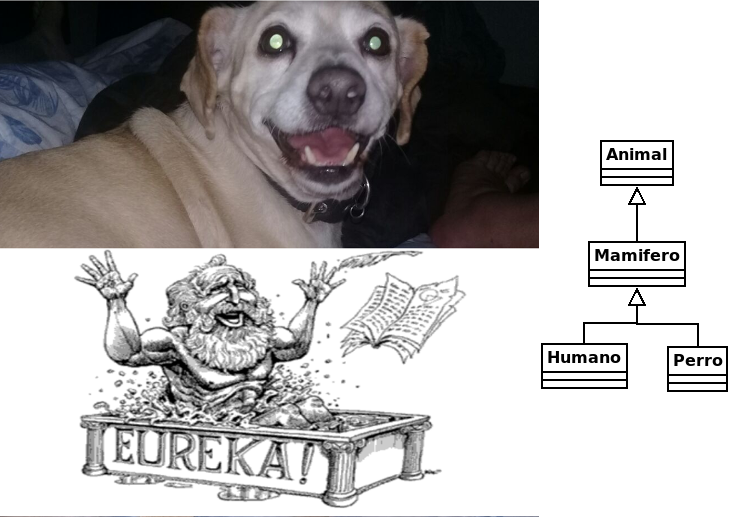

### POO - Propiedades - Herencia
#### Empezamos con los problemas
----------
<small>Pero los requerimientos cambian<small>

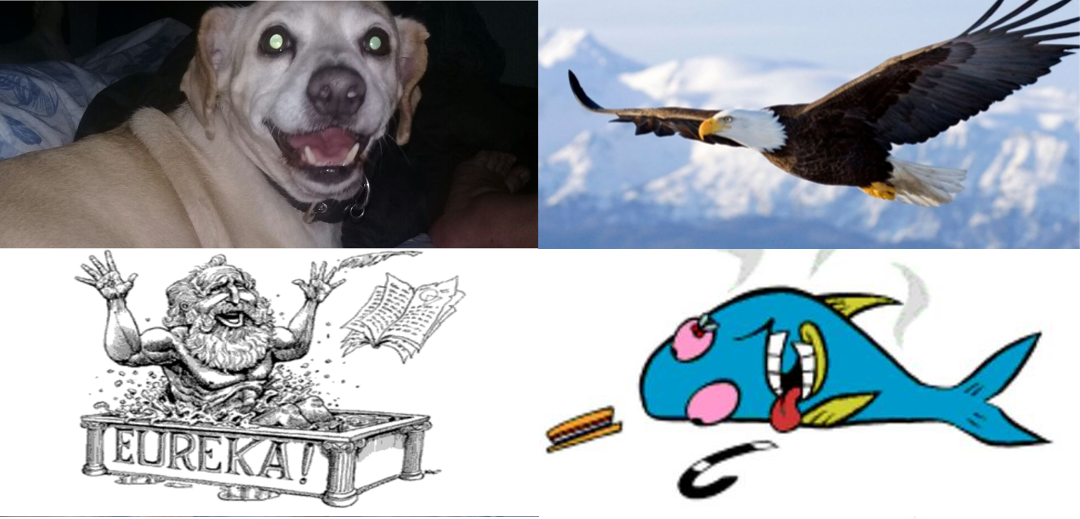

### POO - Propiedades - Herencia
#### Empezamos con los problemas
----------

In [ ]:
class Oviparo(Animal): 
    def nacer(self):
        return "de un huevo"

class Ave(Oviparo): pass

class Pez(Oviparo): pass

rupert = Pez("Rupert")
freedom = Ave("Freedom")    

In [ ]:
isinstance(rupert, Animal), isinstance(freedom, Mamifero), isinstance(rupert, (Ave, Oviparo))

In [ ]:
issubclass(Ave, Oviparo)

### POO - Propiedades - Herencia
#### Empezamos con los problemas
----------

Ahora pasamos a esto

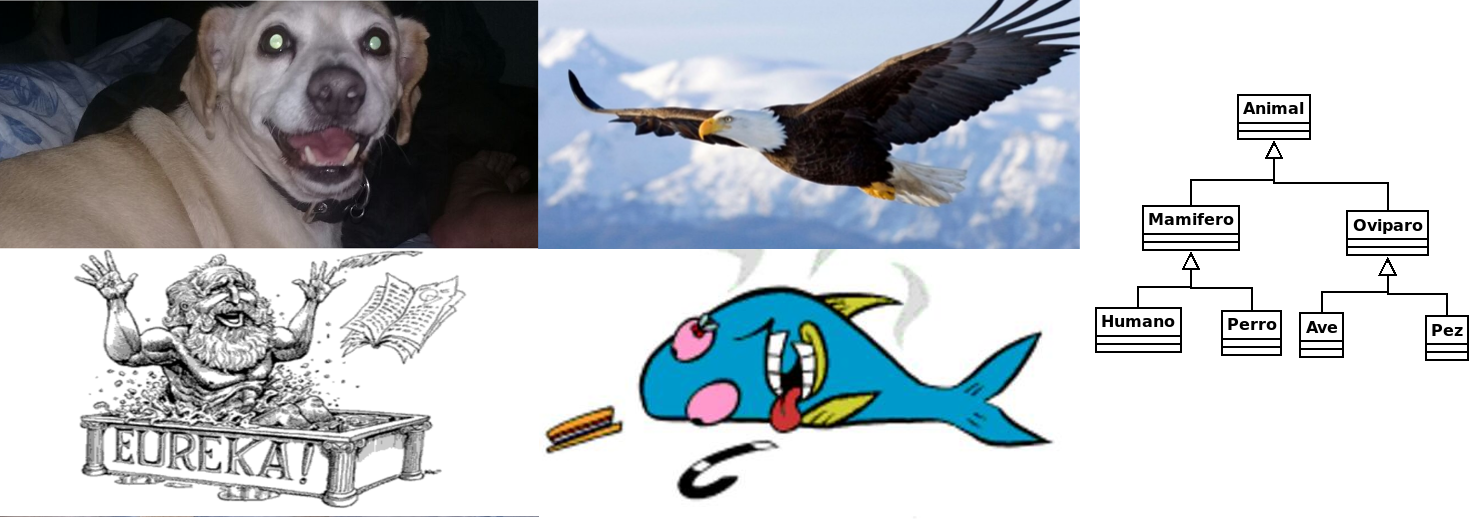

### POO - Propiedades - Herencia
#### Empezamos con los problemas
----------
Peero la realidad es complicada

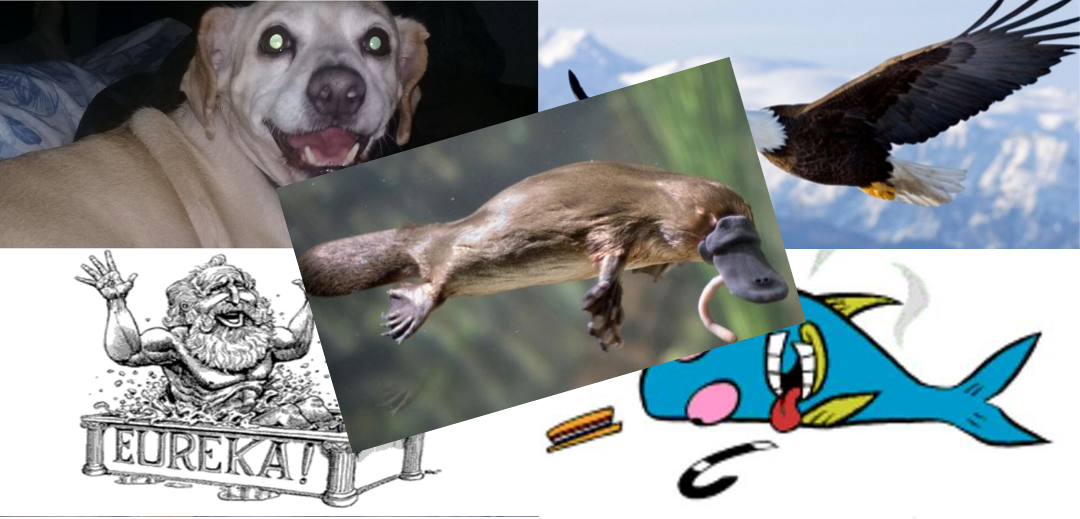

### POO - Propiedades - Herencia
#### Herencia múltiple
----------

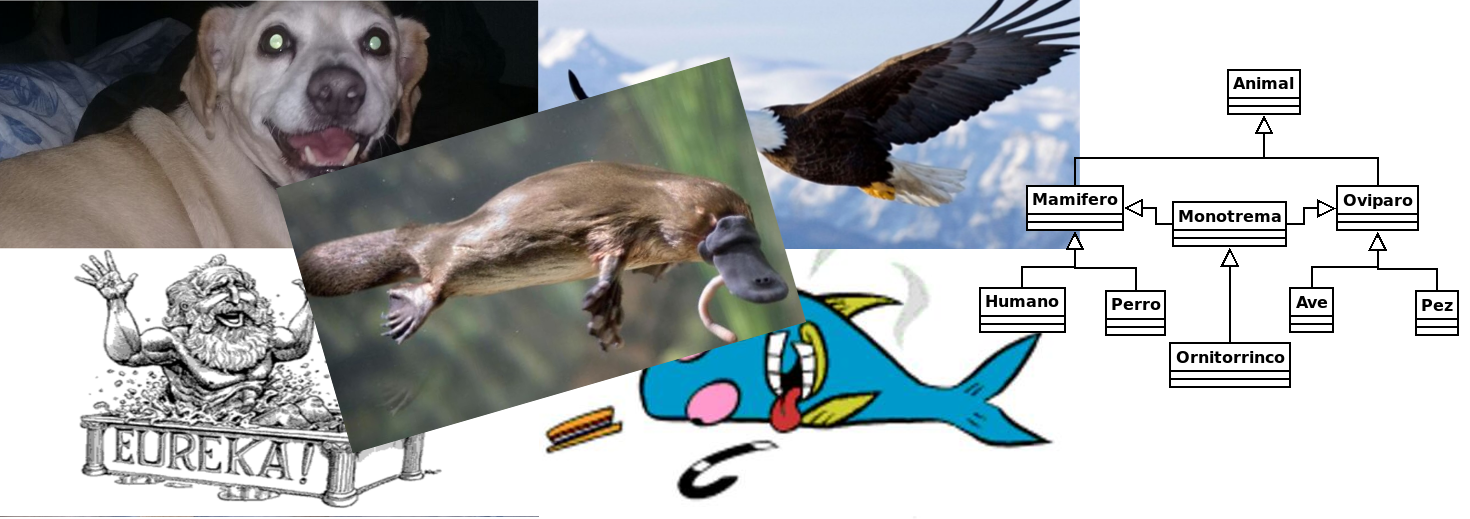

### POO - Propiedades - Herencia
#### Herencia múltiple
----------

In [ ]:
class Monotrema(Oviparo, Mamifero):
    pass

class Ornitorrinco(Monotrema):
    pass

Ornitorrinco.mro()

In [ ]:
orni = Ornitorrinco("ornitorrinco")
orni.nacer(), orni.lactar()

### POO - Propiedades - Herencia
#### Herencia múltiple, problemas
----------

In [ ]:
class Monotrema(Oviparo, Mamifero):
    pass

class Ornitorrinco(Monotrema):
    pass

orni = Ornitorrinco("ornitorrinco")
orni.nacer(), orni.lactar()

In [ ]:
Ornitorrinco.__mro__

### POO - Cerrando Herencia Multiple

----

- Los detractores señalan que hay problemas de implementación de la herencia múltiple.
- Hay lenguajes que solucionan todos los problemas técnicos de la herencia múltiple, pero el debate principal sigue sobre si implementar y usar herencia múltiple es más fácil que usar herencia simple.
- Java, Nemerle, Delphi, C# y Objective-C no permiten herencia múltiple, pero tienen otros mecanismos para simularla.
- Para evitar estos problemas existe un varios patrones: **Mixin**, **Traits** e **Interfaces**

### POO - Cerrando Herencia Multiple - Mixins

----

- Un mixin es una clase que ofrece cierta funcionalidad para ser heredada por una subclase, pero no está ideada para ser autónoma. 
- Heredar de un mixin no es una forma de especialización sino más bien un medio de obtener funcionalidad. 
- Una subclase puede incluso escoger heredar gran parte o el total de su funcionalidad heredando de uno o más mixins mediante herencia múltiple.
- En cristiano: **un mixin tiene comportamiento parcial de un objeto**

### POO - Cerrando Herencia Multiple - Mixins

----

En nuesto caso

In [ ]:
class LactarMixin:
    def lactar(self):
        return "lactando"
    
class NacerDeHuevoMixin:
    def nacer(self):
        return "de huevo"
    
class NacerDeHembraMixin:
    def nacer(self):
        return "de hembra"


class Mamifero(LactarMixin, NacerDeHembraMixin, Animal): pass
class Oviparo(NacerDeHuevoMixin, Animal): pass
class Monotrema(LactarMixin, NacerDeHuevoMixin, Animal): pass

### POO - Cerrando Herencia Multiple - Traits 

----

- un **Trait** es un concepto utilizado en la programación orientada a objetos que representa un conjunto de métodos que pueden utilizarse para ampliar la funcionalidad de una clase.
- No tiene estado (osea no puede nunca hacer un `self.x = "algo"`)

### POO - Cerrando Herencia Multiple - Interfaces

----

- un **Trait** es un concepto utilizado en la programación orientada a objetos que representa un conjunto de métodos que pueden utilizarse para ampliar la funcionalidad de una clase.
- No tiene estado (osea no puede nunca hacer un `self.x = "algo"`)

#### POO - Polimorfismo
----

- El polimorfismo se refiere a la propiedad por la que es posible enviar mensajes sintácticamente iguales a objetos de tipos distintos. 
- El único requisito que deben cumplir los objetos que se utilizan de manera polimórfica es saber responder al mensaje que se les envía.

In [ ]:
for obj in [arqui_p, arqui_h, rupert, freedom, orni]:
    print(type(obj), obj.vivir())

#### POO - Tipos de polimorfismo

Hay cuatro tipos principales de polimorfismo:

1. Polimorfismo de Subtipos (Herencia)
2. Polimorfismo Paramétrico (Generics)
3. Polimorfismo Ad-hoc (Sobrecarga)
4. Polimorfismo de Coerción

Todos son soportados por Python pero teniendo coerción todos los demás son medio inecesarios

#### POO - Polimorfismo de Subtipos (Herencia)

- Permite que objetos de diferentes clases sean tratados como instancias de una clase base común
- Implementado a través de la herencia y métodos sobreescritos

```python
class Animal:
    def hablar(self):
        pass

class Perro(Animal):
    def hablar(self):
        return "Guau"

class Gato(Animal):
    def hablar(self):
        return "Miau"

def hacer_hablar(animal):
    return animal.hablar()

print(hacer_hablar(Perro()))  # Guau
print(hacer_hablar(Gato()))   # Miau
```

En Python, este tipo de polimorfismo es ampliamente utilizado y forma la base de muchos patrones de diseño orientados a objetos.

#### POO - Polimorfismo Paramétrico (Generics)

- Permite escribir código que puede trabajar con diferentes tipos de datos
- En Python, se implementa principalmente a través de duck typing y hints de tipo

```python
from typing import TypeVar, List

T = TypeVar('T')

def primera_posicion(lista: List[T]) -> T:
    return lista[0]

print(primera_posicion([1, 2, 3]))        # 1
print(primera_posicion(["a", "b", "c"]))  # a
```

En Python, el polimorfismo paramétrico es menos explícito que en lenguajes con sistema de tipos estáticos, pero los type hints proporcionan una forma de indicar la intención.

#### POO - Polimorfismo Paramétrico (Generics) en Java

En Java, se implementa explícitamente usando la sintaxis de generics

```java
import java.util.ArrayList;

public interface List<E> extends Collection<E> {
   
    boolean add(E e);

    // ... otros métodos de la interfaz List
}

public class EjemploGenerics {

    public static void main(String[] args) {
        List<Integer> listaEnteros = new ArrayList<>();
        listaEnteros.add(1);
        listaEnteros.add(2);
        listaEnteros.add(3);

        List<String> listaStrings = new ArrayList<>();
        listaStrings.add("a");
        listaStrings.add("b");
        listaStrings.add("c");
    }
}
```

En Java, los generics proporcionan seguridad de tipos en tiempo de compilación y eliminan la necesidad de casteos explícitos, permitiendo la reutilización de código con diferentes tipos de datos.

#### POO - Polimorfismo Ad-hoc (Sobrecarga)

- Permite que una función tenga múltiples implementaciones basadas en los tipos o número de argumentos
- En Python, se simula usando argumentos por defecto, *args, **kwargs o múltiples métodos

```python
class Calculadora:
    def sumar(self, a, b=None):
        if b is None:
            return a
        return a + b

calc = Calculadora()
print(calc.sumar(5))      # 5
print(calc.sumar(5, 3))   # 8
```

Python no soporta sobrecarga de métodos directamente, pero ofrece flexibilidad en la definición de funciones para lograr efectos similares.

#### POO - Polimorfismo Ad-hoc (Sobrecarga) en Java

- Java soporta la sobrecarga de métodos de forma nativa y explícita
- La resolución del método a llamar se realiza en tiempo de compilación

```java
public class Calculadora {
    // Suma de dos enteros
    public int sumar(int a, int b) {
        return a + b;
    }

    // Suma de tres enteros
    public int sumar(int a, int b, int c) {
        return a + b + c;
    }

    // Suma de dos doubles
    public double sumar(double a, double b) {
        return a + b;
    }

    // Suma de un número variable de enteros
    public double sumar(int a, double b) {
        return b + a;
    }

    public static void main(String[] args) {
        Calculadora calc = new Calculadora();
        calc.sumar(5, 3));           // 8
        calc.sumar(5, 3, 2);        // 10
        calc.sumar(5, 3.5);       // 9.0
        calc.sumar(1, 2, 3, 4, 5);  // 15
    }
}
```

En Java, la sobrecarga de métodos proporciona una forma clara y segura de tipo para manejar operaciones similares con diferentes tipos o números de argumentos, permitiendo una mayor flexibilidad y legibilidad en el diseño de las clases.

#### POO - Polimorfismo de Coerción

- Ocurre cuando un objeto es convertido automáticamente de un tipo a otro
- En Python, es común debido a su sistema de tipos dinámico y duck typing

```python
print(len("Hola"))    # 4 (string)
print(len([1, 2, 3])) # 3 (list)

print(1 + 2.0)        # 3.0 (int convertido a float)
print("2" + str(3))   # "23" (int convertido a str)
```

La coerción en Python permite una gran flexibilidad, haciendo que muchas operaciones funcionen con diversos tipos de datos sin necesidad de conversión explícita.

#### POO - Duck Typing y Polimorfismo

- Duck Typing: "Si camina como un pato y hace cuac como un pato, entonces es un pato"
- Permite el polimorfismo basado en el comportamiento, no en la herencia o tipos explícitos

```python
class Pato:
    def hablar(self):
        return "Cuac!"

class Perro:
    def hablar(self):
        return "Guau!"

def hacer_hablar(animal):
    return animal.hablar()

# Todas estas llamadas funcionan sin necesidad de una clase base común
print(hacer_hablar(Pato()))   # Cuac!
print(hacer_hablar(Perro()))  # Guau!
print(hacer_hablar(Gato()))   # Miau!

# Incluso funciona con cualquier objeto que tenga un método 'hablar'
class Persona:
    def hablar(self):
        return "Hola!"

print(hacer_hablar(Persona()))  # Hola!
```

El duck typing permite un polimorfismo basado en la interfaz implícita de los objetos, sin necesidad de declaraciones de tipo explícitas o relaciones de herencia. Esto proporciona gran flexibilidad, pero requiere una gestión cuidadosa para evitar errores en tiempo de ejecución.

## Una clase no es un tipo

Un tipo define un conjunto de valores y las operaciones que se pueden realizar con ellos.
Una clase es una plantilla para crear objetos, que encapsula datos y comportamiento.

### `isinstance(obj, cls)`
   - Verifica si obj es una instancia de cls o de cualquier subclase de cls.
   - Considera la jerarquía de herencia completa.
   - Es más flexible y se recomienda para verificaciones de tipo en código polimórfico.

### `type(obj) == cls`
   - Compara el tipo exacto de obj con cls.
   - No considera la jerarquía de herencia.
   - Es más estricto y se usa cuando se necesita verificar el tipo exacto de un objeto.


## Por que una llamada a función y mensaje **NO** son lo mismo

Llamar a una función implica solicitar una operación concreta que existe en una dirección de memoria específica. Es un proceso directo y eficiente.
Un mensaje es un mecanismo más complejo de implementar, ya que crea un objeto (el mensaje en sí) y evalúa qué implementación de ese mensaje ejecutar. Esta implementación puede haber sido redefinida por herencia u otros mecanismos como single o multiple-dispatching. Este enfoque ofrece mayor flexibilidad y potencial para el polimorfismo.

Veamos un ejemplo donde pueda implementarse un mensaje, vs una función. https://godbolt.org/z/qT5feWTn3